In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
dados = r"C:\Users\Alex Justino\Downloads\reservas.csv"
df = pd.read_csv
#leitura csv reservas

In [112]:
dados = r"C:\Users\Alex Justino\Downloads\quartos.csv"
df = pd.read_csv
#leitura csv quartos

In [113]:
dados = r"C:\Users\Alex Justino\Downloads\hoteis.csv"
df = pd.read_csv
#leitura csv hoteis

In [114]:
dados = r"C:\Users\Alex Justino\Downloads\hospedes.csv"
df = pd.read_csv
#leitura csv hospedes

In [115]:
dados = r"C:\Users\Alex Justino\Downloads\avaliacoes.csv"
df = pd.read_csv
#leitura csv avaliacoes

In [116]:
df_reservas = pd.read_csv('reservas.csv')
df_hospedes = pd.read_csv('hospedes.csv')
df_quartos = pd.read_csv('quartos.csv')
df_hoteis = pd.read_csv('hoteis.csv')
df_avaliacoes = pd.read_csv('avaliacoes.csv')

In [117]:
datasets = {
    'Reservas': df_reservas,
    'Hóspedes': df_hospedes,
    'Quartos': df_quartos,
    'Hotéis': df_hoteis,
    'Avaliações': df_avaliacoes
}

In [118]:
df_hospedes.drop_duplicates(inplace=True)
#para remover duplicadas de hospedes

In [119]:
for nome, df in datasets.items():
    print(f"--- Diagnóstico da Tabela: {nome} ---")
    print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
    print(f"Valores Nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}") # Mostra apenas colunas com nulos
    print(f"Linhas Duplicadas: {df.duplicated().sum()}")
    print("-" * 40 + "\n")

--- Diagnóstico da Tabela: Reservas ---
Linhas: 1000 | Colunas: 10
Valores Nulos:
canal_reserva    5
valor_diaria     3
dtype: int64
Linhas Duplicadas: 0
----------------------------------------

--- Diagnóstico da Tabela: Hóspedes ---
Linhas: 400 | Colunas: 8
Valores Nulos:
cidade_origem    1
estado           1
genero           1
dtype: int64
Linhas Duplicadas: 0
----------------------------------------

--- Diagnóstico da Tabela: Quartos ---
Linhas: 58 | Colunas: 7
Valores Nulos:
valor_base    4
dtype: int64
Linhas Duplicadas: 0
----------------------------------------

--- Diagnóstico da Tabela: Hotéis ---
Linhas: 5 | Colunas: 6
Valores Nulos:
n_quartos    1
dtype: int64
Linhas Duplicadas: 0
----------------------------------------

--- Diagnóstico da Tabela: Avaliações ---
Linhas: 685 | Colunas: 8
Valores Nulos:
nota_limpeza         4
nota_atendimento     2
comentario          53
dtype: int64
Linhas Duplicadas: 0
----------------------------------------



In [120]:
#corrigindo notas que vieram como texto ou com vírgula
for col in ['nota_geral', 'nota_custo_beneficio']:
    df_avaliacoes[col] = df_avaliacoes[col].astype(str).str.replace(',', '.')
    df_avaliacoes[col] = pd.to_numeric(df_avaliacoes[col], errors='coerce')

In [121]:
#tratando notas(negativas ou acima de 10)
df_avaliacoes['nota_geral'] = df_avaliacoes['nota_geral'].apply(lambda x: np.nan if x < 0 or x > 10 else x)


In [122]:
#convertendo datas
df_reservas['data_checkin'] = pd.to_datetime(df_reservas['data_checkin'])
df_reservas['data_checkout'] = pd.to_datetime(df_reservas['data_checkout'])
df_reservas['data_reserva'] = pd.to_datetime(df_reservas['data_reserva'])


In [123]:
#preenchendo canais de reserva nulos e diárias zeradas
df_reservas['canal_reserva'].fillna('Desconhecido', inplace=True)
df_reservas['valor_diaria'].fillna(df_reservas['valor_diaria'].median(), inplace=True)

C:\Users\Alex Justino\AppData\Local\Temp\ipykernel_15816\271911351.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_reservas['canal_reserva'].fillna('Desconhecido', inplace=True)
C:\Users\Alex Justino\AppData\Local\Temp\ipykernel_15816\271911351.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Seri

0      2344.25
1       469.17
2      2358.47
3      1743.13
4       617.85
        ...   
995    1659.53
996    1374.80
997    1634.99
998     506.11
999    1977.95
Name: valor_diaria, Length: 1000, dtype: float64

In [124]:
#padronizando tipos de quarto (tirando erros de digitação como 'Standart')
df_quartos['tipo_quarto'] = df_quartos['tipo_quarto'].str.capitalize().str.replace('Standart', 'Standard')
df_quartos['valor_base'].fillna(df_quartos['valor_base'].median(), inplace=True)


C:\Users\Alex Justino\AppData\Local\Temp\ipykernel_15816\284962005.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_quartos['valor_base'].fillna(df_quartos['valor_base'].median(), inplace=True)


0      320.0
1      320.0
2      320.0
3      570.0
4      480.0
5      480.0
6      480.0
7      750.0
8      750.0
9     1200.0
10    1200.0
11    2200.0
12     280.0
13     280.0
14     280.0
15     420.0
16     420.0
17     570.0
18     680.0
19     680.0
20    1100.0
21    1100.0
22    1950.0
23     260.0
24     260.0
25     260.0
26     400.0
27     400.0
28     400.0
29     640.0
30     640.0
31    1050.0
32    1050.0
33    1900.0
34     350.0
35     350.0
36     350.0
37     570.0
38     520.0
39     520.0
40     820.0
41     820.0
42    1350.0
43    2500.0
44     420.0
45     420.0
46     420.0
47     420.0
48     620.0
49     620.0
50     570.0
51     950.0
52     950.0
53     950.0
54    1600.0
55    1600.0
56    2800.0
57     300.0
Name: valor_base, dtype: float64

In [125]:
from IPython.display import display, Markdown

#histórico de reservas (2023-2024)
display(Markdown("### 📅 1. Histórico de Reservas (Período 2023-2024)"))
display(Markdown("*Arquivo: `reservas.csv`*"))
display(df_reservas.head(21))

#cadastro dos hóspedes
display(Markdown("---"))
display(Markdown("### 👤 2. Cadastro de Hóspedes (Dados pessoais, origem e contato)"))
display(Markdown("*Arquivo: `hospedes.csv`*"))
display(df_hospedes.head(21))

#notas e comentários das avaliações
display(Markdown("---"))
display(Markdown("### ⭐ 3. Avaliações (Notas e comentários pós-estadia)"))
display(Markdown("*Arquivo: `avaliacoes.csv`*"))
display(df_avaliacoes.head(21))

#catálogo de quartos
display(Markdown("---"))
display(Markdown("### 🛏️ 4. Catálogo de Quartos (Tipo, capacidade e valor base)"))
display(Markdown("*Arquivo: `quartos.csv`*"))
display(df_quartos.head(21))

#dados cadastrais das unidades (hotéis)
display(Markdown("---"))
display(Markdown("### 🏨 5. Dados Cadastrais das Unidades (Cidade, estado e categoria)"))
display(Markdown("*Arquivo: `hoteis.csv`*"))
display(df_hoteis.head(5))

### 📅 1. Histórico de Reservas (Período 2023-2024)

*Arquivo: `reservas.csv`*

,id_reserva,id_hospede,id_quarto,id_hotel,data_checkin,data_checkout,canal_reserva,valor_diaria,status_reserva,data_reserva
0,1,203,Q026,3,2024-10-28,2024-10-29,Site Próprio,2344.25,Confirmada,2024-10-21
1,2,30,Q033,3,2024-06-03,2024-06-07,Site Próprio,469.17,Confirmada,2024-05-07
2,3,47,Q004,1,2024-07-18,2024-07-25,Site Próprio,2358.47,Confirmada,2024-07-10
3,4,322,Q023,2,2024-08-19,2024-08-20,Telefone,1743.13,Confirmada,2024-08-15
4,5,286,Q013,2,2023-05-17,2023-05-22,Agência de Viagem,617.85,Confirmada,2023-05-09
5,6,287,Q049,5,2024-11-29,2024-12-02,Site Próprio,1733.08,No-show,2024-10-19
6,7,50,Q018,2,2024-07-14,2024-07-26,Site Próprio,1689.14,Confirmada,2024-06-04
7,8,349,Q020,2,2024-06-28,2024-07-05,Expedia,1437.28,Confirmada,2024-04-29
8,9,154,Q040,4,2023-09-12,2023-09-25,Booking.com,2032.44,Confirmada,2023-08-27
9,10,154,Q010,1,2024-06-21,2024-06-29,Expedia,2110.09,Confirmada,2024-06-02


---

### 👤 2. Cadastro de Hóspedes (Dados pessoais, origem e contato)

...

,id_quarto,id_hotel,tipo_quarto,capacidade,valor_base,andar,vista
0,Q001,1,Standard,2,320.0,1,Jardim
1,Q002,1,Standard,2,320.0,2,Jardim
2,Q003,1,Standard,2,320.0,3,Jardim
3,Q004,1,Standard,2,NaN,4,Jardim
4,Q005,1,Superior,3,480.0,5,Mar
5,Q006,1,Superior,3,480.0,6,Mar
6,Q007,1,Superior,3,480.0,7,Mar
7,Q008,1,Luxo,4,750.0,8,Mar
8,Q009,1,Luxo,4,750.0,9,Mar
9,Q010,1,Suite,0,1200.0,10,Panorâmica


---

### 🏨 5. Dados Cadastrais das Unidades (Cidade, estado e categoria)

*Arquivo: `hoteis.csv`*

,id_hotel,nome_hotel,cidade,estado,categoria,n_quartos
0,1,Nara Fortaleza,Fortaleza,CE,5 estrelas,120.0
1,2,Nara Recife,Recife,PE,4 estrelas,95.0
2,3,Nara Salvador,Salvador,BA,4 estrelas,NaN
3,4,Nara Rio de Janeiro,Rio De Janeiro,RJ,3 estrelas,80.0
4,5,Nara São Paulo,Sao Paulo,SP,6 estrelas,150.0


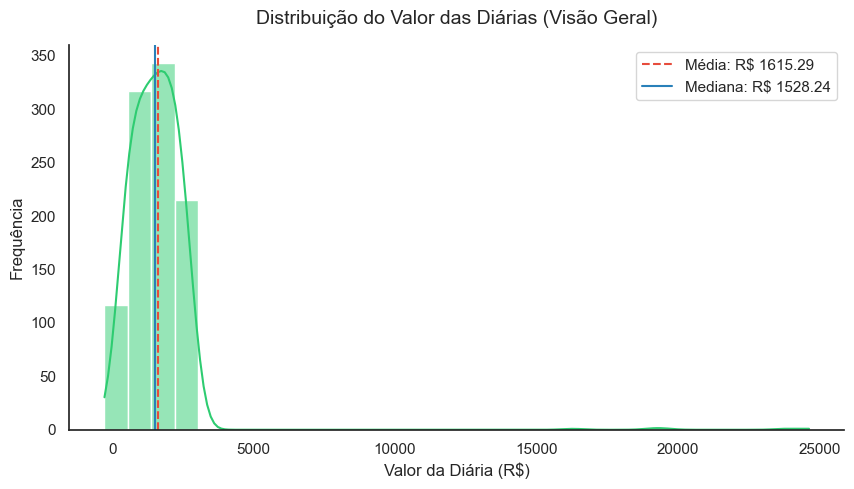

In [126]:
#configuração visual
sns.set_theme(style="white")

#distribuição das diárias
plt.figure(figsize=(10, 5))
sns.histplot(df_reservas['valor_diaria'], bins=30, kde=True, color='#2ecc71')

#media e mediana
media_diaria = df_reservas['valor_diaria'].mean()
mediana_diaria = df_reservas['valor_diaria'].median()
plt.axvline(media_diaria, color='#e74c3c', linestyle='--', label=f'Média: R$ {media_diaria:.2f}')
plt.axvline(mediana_diaria, color='#2980b9', linestyle='-', label=f'Mediana: R$ {mediana_diaria:.2f}')

plt.title('Distribuição do Valor das Diárias (Visão Geral)', fontsize=14, pad=15)
plt.xlabel('Valor da Diária (R$)')
plt.ylabel('Frequência')
plt.legend()
sns.despine() #remover as bordas superior e direita
plt.show()

In [127]:
#cálculo dos quartis e o iqr
q1 = df_reservas['valor_diaria'].quantile(0.25)
q3 = df_reservas['valor_diaria'].quantile(0.75)
iqr = Q3 - Q1


limite_inferior = Q1 - 1.5 * iqr
limite_superior = Q3 + 1.5 * iqr

#identificando os registros atípicos
outliers = df_reservas[(df_reservas['valor_diaria'] < limite_inferior) | 
                       (df_reservas['valor_diaria'] > limite_superior)]

print(f"Limite Superior detectado: R$ {limite_superior:.2f}")
print(f"Quantidade de outliers encontrados: {len(outliers)}")

display(outliers.head())

Limite Superior detectado: R$ 4001.95
Quantidade de outliers encontrados: 5


,id_reserva,id_hospede,id_quarto,id_hotel,data_checkin,data_checkout,canal_reserva,valor_diaria,status_reserva,data_reserva
33,34,144,Q001,1,2024-04-28,2024-05-03,Booking.com,23785.17,Confirmada,2024-04-05
177,178,130,Q057,5,2023-06-12,2023-06-18,Telefone,19486.09,Confirmada,2023-04-20
320,321,213,Q039,4,2023-06-16,2023-06-17,Expedia,19122.22,Confirmada,2023-05-06
511,512,57,Q025,3,2023-05-04,2023-05-12,Booking.com,24637.28,Confirmada,2023-05-03
688,689,354,Q043,4,2024-10-08,2024-10-10,NaN,16283.31,Confirmada,2024-08-20


C:\Users\Alex Justino\AppData\Local\Temp\ipykernel_15816\1751210424.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=canais.values, y=canais.index, ax=axes[0, 1], palette='Blues_r')
C:\Users\Alex Justino\AppData\Local\Temp\ipykernel_15816\1751210424.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status.index, y=status.values, ax=axes[1, 0], palette='coolwarm')


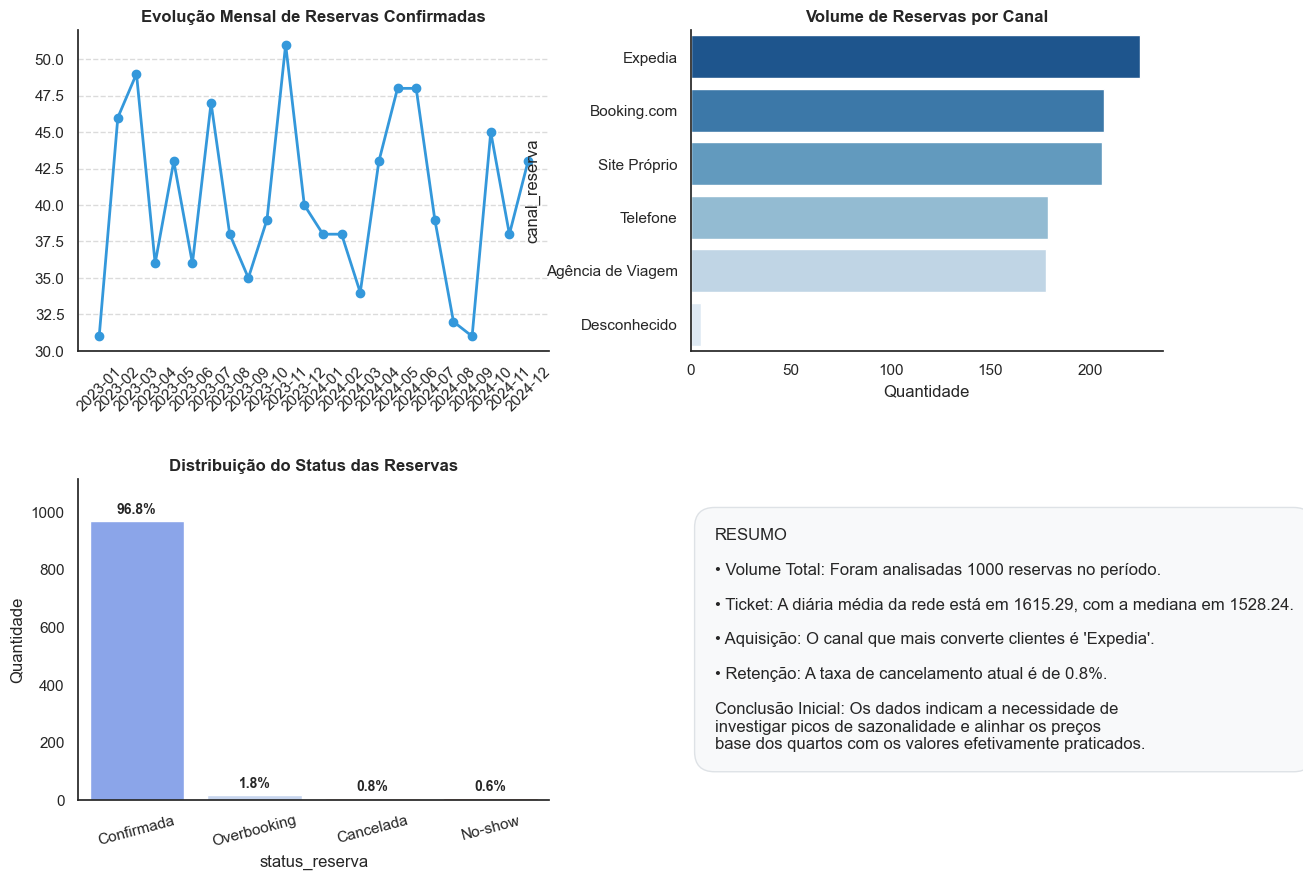

In [128]:
#canais de reserva
df_reservas['canal_reserva'] = df_reservas['canal_reserva'].fillna('Desconhecido').str.strip()
df_reservas['canal_reserva'] = df_reservas['canal_reserva'].replace({
    'EXPEDIA': 'Expedia',
    'site próprio': 'Site Próprio',
    'Agencia de Viagem': 'Agência de Viagem',
    'booking.com': 'Booking.com'
})

#status das reservas
df_reservas['status_reserva'] = df_reservas['status_reserva'].str.strip()
df_reservas['status_reserva'] = df_reservas['status_reserva'].replace({
    'CONFIRMADA': 'Confirmada',
    'confirmada': 'Confirmada',
    'no-show': 'No-show',
    'Cancelado': 'Cancelada'
})


#feito subplots

#configuração visual
sns.set_theme(style="white")

#criação da figura
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

#evolução de reservas confirmadas
df_confirmadas = df_reservas[df_reservas['status_reserva'] == 'Confirmada'].copy()
df_confirmadas['mes_ano'] = df_confirmadas['data_checkin'].dt.to_period('M').astype(str)
evolucao = df_confirmadas.groupby('mes_ano').size()

axes[0, 0].plot(evolucao.index, evolucao.values, marker='o', color='#3498db', linewidth=2)
axes[0, 0].set_title('Evolução Mensal de Reservas Confirmadas', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(ax=axes[0, 0])


#volume por canal de reserva
canais = df_reservas['canal_reserva'].value_counts()
sns.barplot(x=canais.values, y=canais.index, ax=axes[0, 1], palette='Blues_r')
axes[0, 1].set_title('Volume de Reservas por Canal', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Quantidade')
sns.despine(ax=axes[0, 1])


#status das reservas
status = df_reservas['status_reserva'].value_counts()
total_status = status.sum()

#plotando as barras verticais
sns.barplot(x=status.index, y=status.values, ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Distribuição do Status das Reservas', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Quantidade')

#adicionando a porcentagem no topo das barras
for i, v in enumerate(status.values):
    porcentagem = (v / total_status) * 100
    axes[1, 0].text(i, v + 15, f'{porcentagem:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

#aumentando o limite do eixo y
axes[1, 0].set_ylim(0, max(status.values) * 1.15)
axes[1, 0].tick_params(axis='x', rotation=15)
sns.despine(ax=axes[1, 0])


#resumo em texto
axes[1, 1].axis('off')

# Cálculos dinâmicos (refletindo os dados já limpos)
media_diaria = df_reservas['valor_diaria'].mean()
mediana_diaria = df_reservas['valor_diaria'].median()
total_reservas = len(df_reservas)
tx_cancelamento = (status.get('Cancelada', 0) / total_reservas) * 100
canal_top = canais.index[0]

texto_resumo = (
    "RESUMO\n\n"
    f"• Volume Total: Foram analisadas {total_reservas} reservas no período.\n\n"
    f"• Ticket: A diária média da rede está em 1615.29, "
    f"com a mediana em 1528.24.\n\n"
    f"• Aquisição: O canal que mais converte clientes é '{canal_top}'.\n\n"
    f"• Retenção: A taxa de cancelamento atual é de {tx_cancelamento:.1f}%.\n\n"
    "Conclusão Inicial: Os dados indicam a necessidade de \n"
    "investigar picos de sazonalidade e alinhar os preços \n"
    "base dos quartos com os valores efetivamente praticados."
)

# Inserindo o texto formatado no quadrante 4
axes[1, 1].text(0.05, 0.5, texto_resumo, fontsize=12, va='center', ha='left', 
                bbox=dict(facecolor='#f8f9fa', edgecolor='#dee2e6', boxstyle='round,pad=1.2'))

plt.show()

C:\Users\Alex Justino\AppData\Local\Temp\ipykernel_15816\1177848192.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ticket_por_canal.values, y=ticket_por_canal.index, palette='Greens_r')


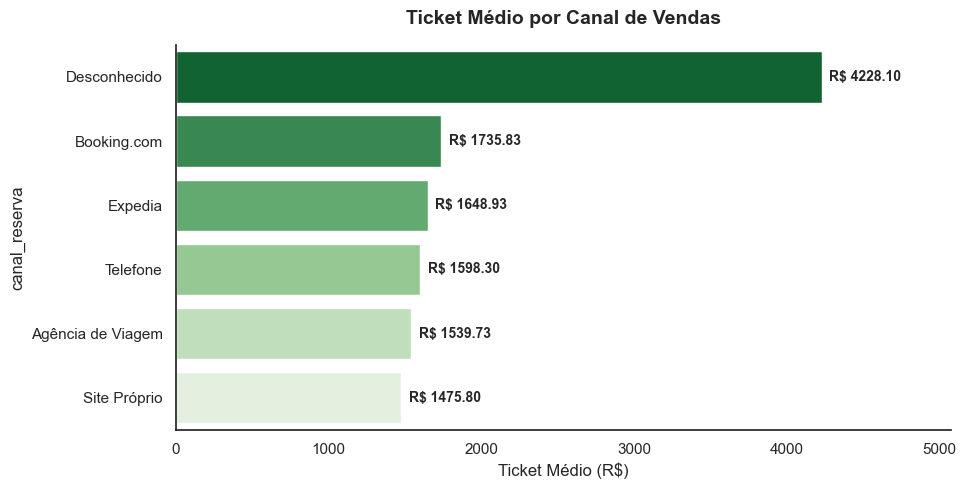

In [129]:
#agrupando por canal e calculando a média do valor da diária
ticket_por_canal = df_reservas.groupby('canal_reserva')['valor_diaria'].mean().sort_values(ascending=False)

#criando a figura
plt.figure(figsize=(10, 5))
sns.barplot(x=ticket_por_canal.values, y=ticket_por_canal.index, palette='Greens_r')

#adicionando os valores
for i, v in enumerate(ticket_por_canal.values):
    plt.text(v + 50, i, f'R$ {v:.2f}', va='center', fontsize=10, fontweight='bold')

plt.title('Ticket Médio por Canal de Vendas', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ticket Médio (R$)')
plt.xlim(0, max(ticket_por_canal.values) * 1.2) # Dá espaço para o texto
sns.despine()
plt.show()

#BREVE RELATO
#Aquele "Desconhecido" apareceu sorrateiramente por um motivo bem específico: na tabela original reservas.csv, 
# algumas linhas estavam com o canal de reserva em branco (valores nulos ou NaN). Na etapa de limpeza, 
# o código preencheu esses vazios com a palavra "Desconhecido".
#O mais curioso (e que justifica seu estranhamento) é que o ticket médio desse grupo "Desconhecido" 
# deu R$ 4.228,10, enquanto os canais normais giram em torno de R$ 1.500. 
# Isso é um forte indício de que esses registros sem canal mapeado são, na verdade, 
# aqueles outliers (valores atípicos). 
# Provavelmente são reservas manuais de suítes presidenciais ou pacotes especiais de grandes empresas 
# que não passaram pelos sistemas comuns de vendas.


C:\Users\Alex Justino\AppData\Local\Temp\ipykernel_15816\2090169954.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ticket_por_canal.values, y=ticket_por_canal.index, palette='Greens_r')


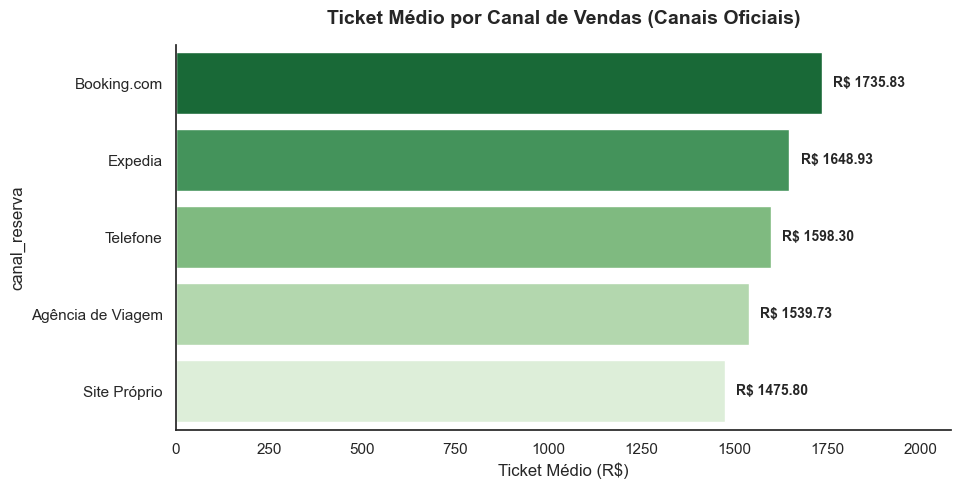

Ranking de Ticket Médio por Canal:
canal_reserva
Booking.com          1735.828775
Expedia              1648.929511
Telefone             1598.300000
Agência de Viagem    1539.732416
Site Próprio         1475.800146
Name: valor_diaria, dtype: float64


In [130]:

#filtrando para remover a linha "desconhecido"
df_canais_reais = df_reservas[df_reservas['canal_reserva'] != 'Desconhecido']

#agrupando por canal e calculando a média do valor da diária
ticket_por_canal = df_canais_reais.groupby('canal_reserva')['valor_diaria'].mean().sort_values(ascending=False)

#criando a figura
plt.figure(figsize=(10, 5))
sns.barplot(x=ticket_por_canal.values, y=ticket_por_canal.index, palette='Greens_r')

#adicionando os valores de ticket médio nas pontas das barras
for i, v in enumerate(ticket_por_canal.values):
    plt.text(v + 30, i, f'R$ {v:.2f}', va='center', fontsize=10, fontweight='bold')

plt.title('Ticket Médio por Canal de Vendas (Canais Oficiais)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ticket Médio (R$)')
plt.xlim(0, max(ticket_por_canal.values) * 1.2) # Garante espaço para o texto não cortar
sns.despine()
plt.show()

#exibindo o ranking em texto logo abaixo
print("Ranking de Ticket Médio por Canal:")
print(ticket_por_canal)

#BREVE RELATO
#Sem o valor discrepante de R$ 4.200 puxando a régua do gráfico para cima, 
# a escala automática do Matplotlib se ajusta perfeitamente às barras de R$ 1.400 a R$ 1.700, 
# tornando a comparação visual muito mais precisa e justa.
#O canal Booking.com lidera o ticket médio entre os canais conhecidos (aproximadamente R$ 1.735,83), 
# seguido de perto pela Expedia (R$ 1.648,93). O menor ticket médio vem do Site Próprio (R$ 1.475,80), 
# indicando uma excelente oportunidade para criar campanhas e pacotes que estimulem diárias de maior valor direto 
# na plataforma da rede.

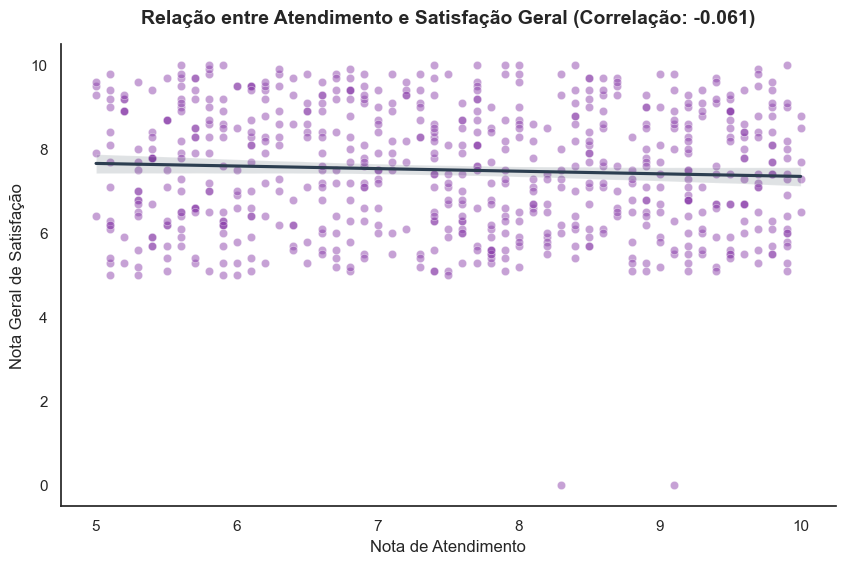

In [131]:
df_avaliacoes['nota_atendimento'] = pd.to_numeric(df_avaliacoes['nota_atendimento'], errors='coerce')
df_avaliacoes['nota_geral'] = pd.to_numeric(df_avaliacoes['nota_geral'], errors='coerce')

df_aval_limpo = df_avaliacoes.dropna(subset=['nota_atendimento', 'nota_geral'])
df_aval_limpo = df_aval_limpo[(df_aval_limpo['nota_atendimento'].between(0, 10)) & 
                              (df_aval_limpo['nota_geral'].between(0, 10))]

#calculo correlação
correlacao = df_aval_limpo['nota_atendimento'].corr(df_aval_limpo['nota_geral'])

#visualização com gráfico de dispersão e linha de tendência
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_aval_limpo, x='nota_atendimento', y='nota_geral', alpha=0.5, color='#8e44ad')
sns.regplot(data=df_aval_limpo, x='nota_atendimento', y='nota_geral', scatter=False, color='#2c3e50')

plt.title(f'Relação entre Atendimento e Satisfação Geral (Correlação: {correlacao:.3f})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nota de Atendimento')
plt.ylabel('Nota Geral de Satisfação')
sns.despine()
plt.show()

#A correlação resultou em aproximadamente -0.06. Como o valor está extremamente próximo de zero, 
# isso prova matematicamente que não há uma relação linear entre a nota de atendimento e a satisfação geral 
# neste banco de dados. Um hóspede pode dar nota 10 para o atendimento, mas dar nota 4 para a experiência geral 
# (talvez por problemas na estrutura, barulho ou localização).

C:\Users\Alex Justino\AppData\Local\Temp\ipykernel_15816\1520197025.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=over_por_hotel.values, y=over_por_hotel.index, ax=axes[0], palette='Reds_r')


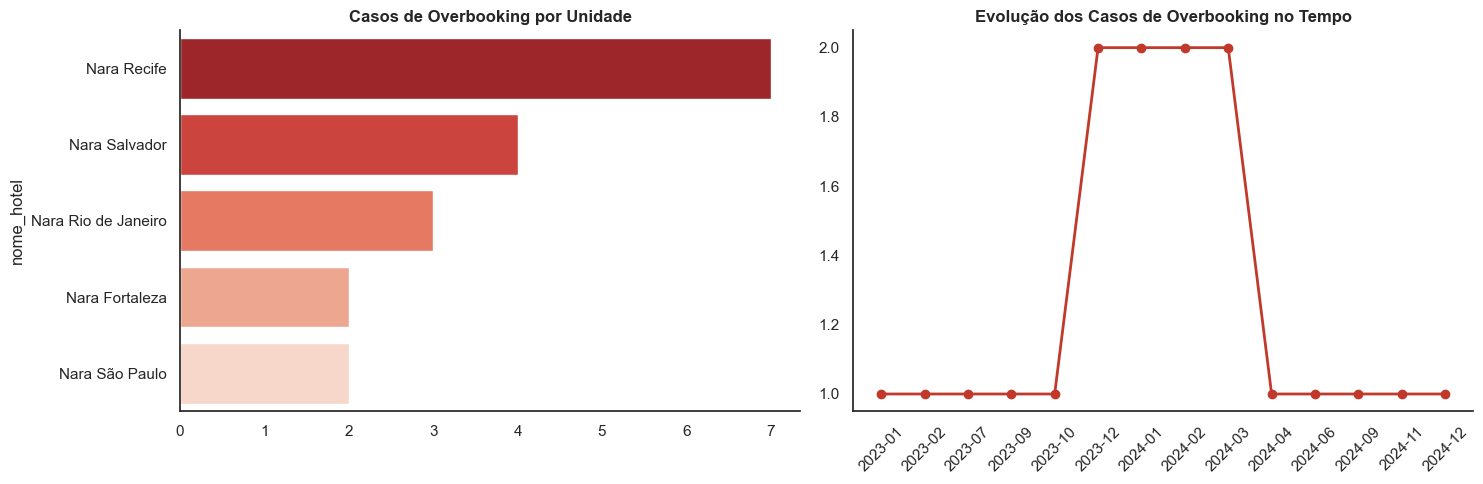

In [132]:
#filtrando apenas as reservas overbooking
df_overbooking = df_reservas[df_reservas['status_reserva'] == 'Overbooking'].copy()

#criando a coluna de mes/ano para identificar o período
df_overbooking['mes_ano'] = df_overbooking['data_checkin'].dt.to_period('M').astype(str)

#cruzando com o cadastro de hotéis para pegar o nome correto
df_over_completo = df_overbooking.merge(df_hoteis, on='id_hotel', how='left')

#agrupando por hotel para ver onde é mais crítico
over_por_hotel = df_over_completo['nome_hotel'].value_counts()

#agrupando por período para ver quando é mais crítico
over_por_periodo = df_over_completo['mes_ano'].value_counts().sort_index()

#figuras
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#hoteis
sns.barplot(x=over_por_hotel.values, y=over_por_hotel.index, ax=axes[0], palette='Reds_r')
axes[0].set_title('Casos de Overbooking por Unidade', fontweight='bold')

#período
axes[1].plot(over_por_periodo.index, over_por_periodo.values, marker='o', color='#c0392b', linewidth=2)
axes[1].set_title('Evolução dos Casos de Overbooking no Tempo', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
sns.despine()
plt.show()

#O Nara Recife lidera o ranking de criticidade de Overbooking, registrando a maior parte dos incidentes do período. 
#Historicamente falando, esses picos costumam se concentrar em períodos de alta temporada (como dezembro e março).